In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
from typing import Dict, List, Tuple, Set, Optional, Any

import torch
from torch_geometric.data import HeteroData


# -----------------------------
# IO / helpers
# -----------------------------
def load_graph(path: str | Path) -> HeteroData:
    g = torch.load(path, weights_only=False)
    if not isinstance(g, HeteroData):
        raise TypeError(f"Expected HeteroData, got {type(g)} from {path}")
    return g


def safe_node_ids(g: HeteroData, ntype: str) -> List[str]:
    if hasattr(g[ntype], "node_ids"):
        return [str(x) for x in g[ntype].node_ids]
    return [f"{ntype}:{i}" for i in range(g[ntype].num_nodes)]


def edge_types_between(g: HeteroData, a: str, b: str) -> List[Tuple[str, str, str]]:
    cands = []
    for et in g.edge_types:
        s, r, t = et
        if (s == a and t == b) or (s == b and t == a):
            cands.append(et)
    nonrev = [e for e in cands if not str(e[1]).startswith("rev_")]
    return nonrev if nonrev else cands


def neighbors_set(
    g: HeteroData,
    edge_types: List[Tuple[str, str, str]],
    src_type: str,
    dst_type: str,
) -> Tuple[List[Set[int]], List[Set[int]]]:
    srcN = [set() for _ in range(g[src_type].num_nodes)]
    dstN = [set() for _ in range(g[dst_type].num_nodes)]

    for (s, r, t) in edge_types:
        ei = g[(s, r, t)].edge_index
        if ei.numel() == 0:
            continue
        a = ei[0].tolist()
        b = ei[1].tolist()

        if s == src_type and t == dst_type:
            for u, v in zip(a, b):
                if 0 <= u < len(srcN) and 0 <= v < len(dstN):
                    srcN[u].add(v)
                    dstN[v].add(u)
        elif s == dst_type and t == src_type:
            for u, v in zip(a, b):
                if 0 <= u < len(dstN) and 0 <= v < len(srcN):
                    dstN[u].add(v)
                    srcN[v].add(u)

    return srcN, dstN


# -----------------------------
# task_type inference (optional)
# -----------------------------
def infer_task_to_task_type(g: HeteroData) -> Dict[int, Optional[int]]:
    if "tasks" not in g.node_types or "task_types" not in g.node_types:
        return {}
    tt_edges = edge_types_between(g, "tasks", "task_types")
    if not tt_edges:
        return {}
    task_to_tt, _ = neighbors_set(g, tt_edges, "tasks", "task_types")
    out: Dict[int, Optional[int]] = {}
    for t_idx, tt_set in enumerate(task_to_tt):
        out[t_idx] = next(iter(tt_set)) if tt_set else None
    return out


# -----------------------------
# core verification
# -----------------------------
def compute_engineer_task_sets(g: HeteroData):
    for need in ["engineers", "assignments", "tasks"]:
        if need not in g.node_types:
            raise ValueError(f"Missing node type {need!r}. node_types={g.node_types}")

    ea_edges = edge_types_between(g, "engineers", "assignments")
    at_edges = edge_types_between(g, "assignments", "tasks")
    if not ea_edges:
        raise ValueError("No edge types found between engineers and assignments.")
    if not at_edges:
        raise ValueError("No edge types found between assignments and tasks.")

    # engineer -> assignments
    e_to_a, _ = neighbors_set(g, ea_edges, "engineers", "assignments")
    # assignment -> engineers
    _, a_to_e = neighbors_set(g, ea_edges, "engineers", "assignments")

    # assignment -> tasks
    a_to_t, _ = neighbors_set(g, at_edges, "assignments", "tasks")
    # task -> assignments
    _, t_to_a = neighbors_set(g, at_edges, "assignments", "tasks")

    # task -> engineers via assignments
    t_to_e: List[Set[int]] = [set() for _ in range(g["tasks"].num_nodes)]
    for t_idx, a_set in enumerate(t_to_a):
        es = set()
        for a in a_set:
            es.update(a_to_e[a])
        t_to_e[t_idx] = es

    # engineer -> tasks via assignments
    e_to_tasks: List[Set[int]] = [set() for _ in range(g["engineers"].num_nodes)]
    for e_idx, a_set in enumerate(e_to_a):
        ts = set()
        for a in a_set:
            ts.update(a_to_t[a])
        e_to_tasks[e_idx] = ts

    return e_to_tasks, t_to_e


def top_engineers_by_task_count(e_to_tasks: List[Set[int]], k: int) -> List[int]:
    counts = [(i, len(s)) for i, s in enumerate(e_to_tasks)]
    counts.sort(key=lambda x: x[1], reverse=True)
    return [i for i, _ in counts[:k]]


def verify_elite_engineers(
    g: HeteroData,
    *,
    topk: int = 20,
    partner_topk: int = 10,
    max_print_tasktypes: int = 15,
    verbose: bool = True,
) -> Dict[str, Any]:
    """
    Notebook-friendly:
      - no argparse
      - returns a structured dict so you can inspect/plot
    """
    eng_ids = safe_node_ids(g, "engineers")
    task_ids = safe_node_ids(g, "tasks")

    e_to_tasks, t_to_e = compute_engineer_task_sets(g)

    task_to_tt = infer_task_to_task_type(g)
    task_type_ids = safe_node_ids(g, "task_types") if "task_types" in g.node_types else []
    has_task_type = bool(task_to_tt) and bool(task_type_ids)

    elites = top_engineers_by_task_count(e_to_tasks, topk)

    results = {
        "graph": {
            "num_engineers": len(eng_ids),
            "num_tasks": len(task_ids),
            "has_task_type": has_task_type,
        },
        "elites": [],
    }

    if verbose:
        print(f"Graph: engineers={len(eng_ids)}, tasks={len(task_ids)}")
        print(f"TopK elites (by distinct tasks): K={topk}")
        print("=" * 80)

    for rank, e_idx in enumerate(elites, start=1):
        e_name = eng_ids[e_idx]
        tasks = e_to_tasks[e_idx]
        tc = len(tasks)

        size_dist = Counter()
        two_partner_counter = Counter()
        tasktype_dist = Counter()

        for t in tasks:
            workers = t_to_e[t]
            sz = len(workers)
            size_dist[sz] += 1

            if sz == 2 and e_idx in workers:
                other = next(iter(workers - {e_idx}))
                two_partner_counter[eng_ids[other]] += 1

            if has_task_type:
                tt = task_to_tt.get(t, None)
                if tt is None:
                    tasktype_dist["<unknown>"] += 1
                else:
                    if 0 <= tt < len(task_type_ids):
                        tasktype_dist[task_type_ids[tt]] += 1
                    else:
                        tasktype_dist["<out_of_range>"] += 1

        two = size_dist.get(2, 0)
        two_share = two / max(tc, 1)

        elite_rec = {
            "rank": rank,
            "engineer": e_name,
            "distinct_task_count": tc,
            "worker_group_size_dist": dict(size_dist),
            "share_group_size_2": two_share,
            "partners_in_size2_unique": len(two_partner_counter),
            "top_partners_in_size2": two_partner_counter.most_common(partner_topk),
            "task_type_dist": tasktype_dist.most_common(max_print_tasktypes) if has_task_type else None,
        }
        results["elites"].append(elite_rec)

        if verbose:
            print(f"[rank {rank:>2}] engineer={e_name}")
            print(f"  distinct_task_count: {tc}")
            print(f"  worker_group_size_dist (top): {dict(size_dist.most_common(8))}")
            print(f"  share(group_size==2): {two_share:.3f}  ( {two} / {tc} )")
            print(f"  partners_in_size2_tasks: unique={len(two_partner_counter)}")
            if two_partner_counter:
                print("  top partners (count in size=2 tasks):")
                for p, c in two_partner_counter.most_common(partner_topk):
                    print(f"    - {p}: {c}")
            else:
                print("  top partners: <none>")

            if has_task_type:
                print(f"  task_type_dist (top {max_print_tasktypes}):")
                for tt, c in tasktype_dist.most_common(max_print_tasktypes):
                    print(f"    - {tt}: {c}")
            else:
                print("  task_type_dist: <unavailable>")

            print("-" * 80)

    return results


In [2]:
g = load_graph("data/graph/sdge.pt")

res = verify_elite_engineers(
    g,
    topk=20,
    partner_topk=10,
    max_print_tasktypes=15,
    verbose=True,
)
res


Graph: engineers=10941, tasks=5408813
TopK elites (by distinct tasks): K=20
[rank  1] engineer=SPS_1_OXN_SPERLING
  distinct_task_count: 8816
  worker_group_size_dist (top): {1: 8816}
  share(group_size==2): 0.000  ( 0 / 8816 )
  partners_in_size2_tasks: unique=0
  top partners: <none>
  task_type_dist (top 15):
    - CP AREA READS MAG SCG: 6303
    - CP AREA READS IMP SCG: 1627
    - CP10 READS SAP SCG CPD: 803
    - CP10 TRBL SHOOT SCG CPD: 57
    - CP AREA TROUBLESHOOTING IMP SCG: 14
    - CP AREA TROUBLESHOOTING MAG SCG: 10
    - MISC CP AREA READS IMP SCG: 2
--------------------------------------------------------------------------------
[rank  2] engineer=SPS_1_GLN_LUNA
  distinct_task_count: 8415
  worker_group_size_dist (top): {1: 8415}
  share(group_size==2): 0.000  ( 0 / 8415 )
  partners_in_size2_tasks: unique=0
  top partners: <none>
  task_type_dist (top 15):
    - CP AREA READS MAG SCG: 5597
    - CP AREA READS IMP SCG: 1476
    - CP10 READS SAP SCG CPD: 1218
    - CP ARE

{'graph': {'num_engineers': 10941,
  'num_tasks': 5408813,
  'has_task_type': True},
 'elites': [{'rank': 1,
   'engineer': 'SPS_1_OXN_SPERLING',
   'distinct_task_count': 8816,
   'worker_group_size_dist': {1: 8816},
   'share_group_size_2': 0.0,
   'partners_in_size2_unique': 0,
   'top_partners_in_size2': [],
   'task_type_dist': [('CP AREA READS MAG SCG', 6303),
    ('CP AREA READS IMP SCG', 1627),
    ('CP10 READS SAP SCG CPD', 803),
    ('CP10 TRBL SHOOT SCG CPD', 57),
    ('CP AREA TROUBLESHOOTING IMP SCG', 14),
    ('CP AREA TROUBLESHOOTING MAG SCG', 10),
    ('MISC CP AREA READS IMP SCG', 2)]},
  {'rank': 2,
   'engineer': 'SPS_1_GLN_LUNA',
   'distinct_task_count': 8415,
   'worker_group_size_dist': {1: 8415},
   'share_group_size_2': 0.0,
   'partners_in_size2_unique': 0,
   'top_partners_in_size2': [],
   'task_type_dist': [('CP AREA READS MAG SCG', 5597),
    ('CP AREA READS IMP SCG', 1476),
    ('CP10 READS SAP SCG CPD', 1218),
    ('CP AREA TROUBLESHOOTING MAG SCG', 61),

In [4]:
from collections import Counter, defaultdict

def analyze_small_task_engineers(
    g,
    *,
    min_tasks: int = 2,
    max_tasks: int = 20,
    max_engineers_print: int = 30,
    max_tasktypes_print: int = 10,
):
    eng_ids = safe_node_ids(g, "engineers")
    e_to_tasks, t_to_e = compute_engineer_task_sets(g)

    task_to_tt = infer_task_to_task_type(g)
    task_type_ids = safe_node_ids(g, "task_types") if "task_types" in g.node_types else []
    has_task_type = bool(task_to_tt) and bool(task_type_ids)

    # engineer -> task_count
    task_counts = [(i, len(ts)) for i, ts in enumerate(e_to_tasks)]
    
    # filter
    target = [
        (i, c) for i, c in task_counts
        if min_tasks <= c <= max_tasks
    ]

    print(f"Engineers with {min_tasks} <= task_count <= {max_tasks}: {len(target)}")
    print("=" * 80)

    results = []

    for idx, (e_idx, tc) in enumerate(target[:max_engineers_print], start=1):
        name = eng_ids[e_idx]
        tasks = e_to_tasks[e_idx]

        size_dist = Counter()
        tasktype_dist = Counter()

        for t in tasks:
            size_dist[len(t_to_e[t])] += 1
            if has_task_type:
                tt = task_to_tt.get(t)
                if tt is None:
                    tasktype_dist["<unknown>"] += 1
                else:
                    tasktype_dist[task_type_ids[tt]] += 1

        rec = {
            "engineer": name,
            "task_count": tc,
            "worker_group_size_dist": dict(size_dist),
            "task_type_dist": tasktype_dist.most_common(max_tasktypes_print),
        }
        results.append(rec)

        # pretty print
        print(f"[{idx:>2}] engineer={name}")
        print(f"  task_count={tc}")
        print(f"  worker_group_size_dist={dict(size_dist)}")
        if has_task_type:
            print("  task_type_dist:")
            for tt, c in tasktype_dist.most_common(max_tasktypes_print):
                print(f"    - {tt}: {c}")
        print("-" * 80)

    return results

small_eng = analyze_small_task_engineers(
    g,
    min_tasks=2,
    max_tasks=20,
    max_engineers_print=40,
)



Engineers with 2 <= task_count <= 20: 767
[ 1] engineer=ALAYZA CREW TEST
  task_count=3
  worker_group_size_dist={1: 3}
  task_type_dist:
    - GAS RULE 16 RES NON RES 04 SDG CPD: 1
    - SERVICE REPAIR SDE: 1
    - CURB VALVE INSPECTION SDG: 1
--------------------------------------------------------------------------------
[ 2] engineer=ALVAREZ MARIO
  task_count=3
  worker_group_size_dist={1: 3}
  task_type_dist:
    - CORRECTIVE MAINT DIST REG STA SCG: 1
    - DRS CHNGOUT NEW LOCATION SCG CPD: 1
    - DRS REMOVAL SCG CPD: 1
--------------------------------------------------------------------------------
[ 3] engineer=AMES LARRY
  task_count=4
  worker_group_size_dist={1: 4}
  task_type_dist:
    - LINE REPAIR SDE: 3
    - FAULT VAN SDE: 1
--------------------------------------------------------------------------------
[ 4] engineer=BAUERS RONALD
  task_count=2
  worker_group_size_dist={1: 2}
  task_type_dist:
    - FAULT VAN SDE: 2
---------------------------------------------------

In [5]:
from collections import Counter

def analyze_mid_task_engineers(
    g,
    *,
    min_tasks: int = 50,
    max_tasks: int = 200,
    max_engineers_print: int = 30,
    max_tasktypes_print: int = 12,
):
    eng_ids = safe_node_ids(g, "engineers")
    e_to_tasks, t_to_e = compute_engineer_task_sets(g)

    task_to_tt = infer_task_to_task_type(g)
    task_type_ids = safe_node_ids(g, "task_types") if "task_types" in g.node_types else []
    has_task_type = bool(task_to_tt) and bool(task_type_ids)

    # engineer -> task_count
    task_counts = [(i, len(ts)) for i, ts in enumerate(e_to_tasks)]

    target = [
        (i, c) for i, c in task_counts
        if min_tasks <= c <= max_tasks
    ]

    print(f"Engineers with {min_tasks} <= task_count <= {max_tasks}: {len(target)}")
    print("=" * 80)

    results = []

    for idx, (e_idx, tc) in enumerate(target[:max_engineers_print], start=1):
        name = eng_ids[e_idx]
        tasks = e_to_tasks[e_idx]

        size_dist = Counter()
        tasktype_dist = Counter()

        for t in tasks:
            size_dist[len(t_to_e[t])] += 1
            if has_task_type:
                tt = task_to_tt.get(t)
                if tt is None:
                    tasktype_dist["<unknown>"] += 1
                else:
                    tasktype_dist[task_type_ids[tt]] += 1

        rec = {
            "engineer": name,
            "task_count": tc,
            "worker_group_size_dist": dict(size_dist),
            "task_type_dist": tasktype_dist.most_common(max_tasktypes_print),
        }
        results.append(rec)

        # pretty print
        print(f"[{idx:>2}] engineer={name}")
        print(f"  task_count={tc}")
        print(f"  worker_group_size_dist={dict(size_dist)}")
        if has_task_type:
            print("  task_type_dist:")
            for tt, c in tasktype_dist.most_common(max_tasktypes_print):
                print(f"    - {tt}: {c}")
        print("-" * 80)

    return results

mid_eng = analyze_mid_task_engineers(
    g,
    min_tasks=50,
    max_tasks=200,
    max_engineers_print=40,
)

mid_eng

Engineers with 50 <= task_count <= 200: 1029
[ 1] engineer= CLEAN UP_SNM
  task_count=99
  worker_group_size_dist={1: 99}
  task_type_dist:
    - SVC RPL 3IN OR LESS DBURY PLASTIC SCG CPD: 14
    - MSA INSTALL SCG CPD: 11
    - SVC RPL 3IN OR LESS  INSRT PLASTIC SCG CPD: 10
    - REPAIR REBUILD OR REMOVE REG TAP FAC SCG: 8
    - LEAK REPAIR MAIN SCG: 4
    - MSA CHANGEOUT EXISTING MR ACCT SCG CPD: 4
    - UNUSUAL CNSMPTION SAMR OR MRMR SCG: 4
    - COMP SVC ABANDON OR REMOVAL SCG: 2
    - COMP 3IN AND UNDER INS OR PL REPL SERVICE SCG: 2
    - LEAK REPAIR SERVICE SCG: 2
    - LG ALT OR REBUILD OR REPLACE SCG: 2
    - SERVICE ISO ALT OR REIN MAINT SCG: 2
--------------------------------------------------------------------------------
[ 2] engineer=BC OH INSP 4
  task_count=135
  worker_group_size_dist={1: 135}
  task_type_dist:
    - OHVI FOLLOW UP SDE: 112
    - SERVICE REPAIR SDE: 15
    - MISC OHVI FOLLOW-UP SDE: 3
    - OH QC FOLLOW UP SDE: 2
    - LINE REPAIR SDE: 1
    - OH PATROL 

[{'engineer': ' CLEAN UP_SNM',
  'task_count': 99,
  'worker_group_size_dist': {1: 99},
  'task_type_dist': [('SVC RPL 3IN OR LESS DBURY PLASTIC SCG CPD', 14),
   ('MSA INSTALL SCG CPD', 11),
   ('SVC RPL 3IN OR LESS  INSRT PLASTIC SCG CPD', 10),
   ('REPAIR REBUILD OR REMOVE REG TAP FAC SCG', 8),
   ('LEAK REPAIR MAIN SCG', 4),
   ('MSA CHANGEOUT EXISTING MR ACCT SCG CPD', 4),
   ('UNUSUAL CNSMPTION SAMR OR MRMR SCG', 4),
   ('COMP SVC ABANDON OR REMOVAL SCG', 2),
   ('COMP 3IN AND UNDER INS OR PL REPL SERVICE SCG', 2),
   ('LEAK REPAIR SERVICE SCG', 2),
   ('LG ALT OR REBUILD OR REPLACE SCG', 2),
   ('SERVICE ISO ALT OR REIN MAINT SCG', 2)]},
 {'engineer': 'BC OH INSP 4',
  'task_count': 135,
  'worker_group_size_dist': {1: 135},
  'task_type_dist': [('OHVI FOLLOW UP SDE', 112),
   ('SERVICE REPAIR SDE', 15),
   ('MISC OHVI FOLLOW-UP SDE', 3),
   ('OH QC FOLLOW UP SDE', 2),
   ('LINE REPAIR SDE', 1),
   ('OH PATROL FOLLOW UP SDE', 1),
   ('OH MISC CORR MAINT PROG SDE CPD', 1)]},
 {'e

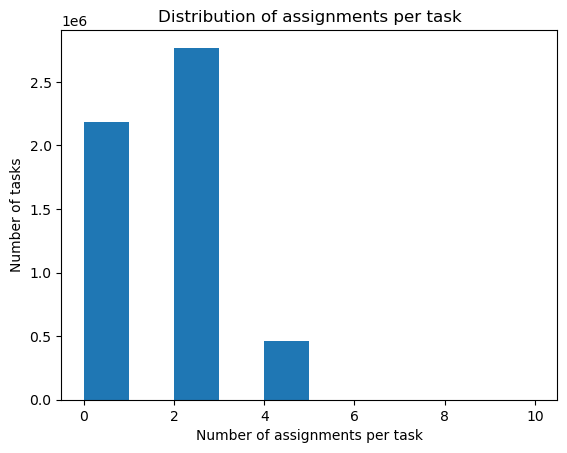

assignment_count -> number_of_tasks (top 10):
2: 2768311
0: 2182158
4: 458338
6: 5
10: 1


Counter({2: 2768311, 0: 2182158, 4: 458338, 6: 5, 10: 1})

In [6]:
from collections import Counter
import matplotlib.pyplot as plt

def plot_assignments_per_task_histogram(g, bins=50, log_y=False):
    # 找 assignment ↔ task 的边
    def edge_types_between(g, a, b):
        cands = []
        for et in g.edge_types:
            s, r, t = et
            if (s == a and t == b) or (s == b and t == a):
                cands.append(et)
        nonrev = [e for e in cands if not str(e[1]).startswith("rev_")]
        return nonrev if nonrev else cands

    at_edges = edge_types_between(g, "assignments", "tasks")
    if not at_edges:
        raise ValueError("No assignment–task edges found")

    # 统计每个 task 的 assignment 数
    task_assignment_count = Counter()
    num_tasks = g["tasks"].num_nodes

    for (s, r, t) in at_edges:
        ei = g[(s, r, t)].edge_index
        src = ei[0].tolist()
        dst = ei[1].tolist()

        if s == "assignments" and t == "tasks":
            for _, task in zip(src, dst):
                task_assignment_count[task] += 1
        elif s == "tasks" and t == "assignments":
            for task, _ in zip(src, dst):
                task_assignment_count[task] += 1

    # 补上 assignment=0 的 task（如果存在）
    counts = [task_assignment_count.get(i, 0) for i in range(num_tasks)]

    # 画直方图
    plt.figure()
    plt.hist(counts, bins=bins)
    if log_y:
        plt.yscale("log")
    plt.xlabel("Number of assignments per task")
    plt.ylabel("Number of tasks")
    plt.title("Distribution of assignments per task")
    plt.show()

    # 打印一个紧凑的分布摘要
    dist = Counter(counts)
    print("assignment_count -> number_of_tasks (top 10):")
    for k, v in dist.most_common(10):
        print(f"{k}: {v}")

    return dist


dist = plot_assignments_per_task_histogram(
    g,
    bins=10,
    log_y=False,   # 强烈建议开
)

dist

In [7]:
import random
from collections import defaultdict

def sample_tasks_with_two_assignments(g, sample_n=20, seed=42):
    random.seed(seed)

    # 取 node ids
    task_ids = safe_node_ids(g, "tasks")
    eng_ids = safe_node_ids(g, "engineers")

    # engineer <-> assignment <-> task 映射
    e_to_tasks, t_to_e = compute_engineer_task_sets(g)

    # task -> assignment 数
    # 用 assignments → tasks 的边来算
    at_edges = edge_types_between(g, "assignments", "tasks")
    a_to_t, t_to_a = neighbors_set(g, at_edges, "assignments", "tasks")

    # 找 assignment_count == 2 的 tasks
    candidate_tasks = [
        t_idx for t_idx, a_set in enumerate(t_to_a)
        if len(a_set) == 2
    ]

    print(f"Total tasks with assignment_count == 2: {len(candidate_tasks)}")

    sampled = random.sample(candidate_tasks, min(sample_n, len(candidate_tasks)))

    print("=" * 80)

    for i, t_idx in enumerate(sampled, 1):
        engineers = t_to_e[t_idx]
        eng_names = [eng_ids[e] for e in engineers]

        print(f"[{i:>2}] task={task_ids[t_idx]}")
        print(f"     engineers ({len(eng_names)}):")
        for name in eng_names:
            print(f"       - {name}")
        print("-" * 80)

    return sampled
sampled_tasks = sample_tasks_with_two_assignments(g, sample_n=20)
sampled_tasks

Total tasks with assignment_count == 2: 458338
[ 1] task=4252464
     engineers (0):
--------------------------------------------------------------------------------
[ 2] task=3912111
     engineers (1):
       - CONT_CRN_SE
--------------------------------------------------------------------------------
[ 3] task=3731984
     engineers (0):
--------------------------------------------------------------------------------
[ 4] task=4321181
     engineers (0):
--------------------------------------------------------------------------------
[ 5] task=4008924
     engineers (2):
       - CONT_SNM_SE
       - LCT_1_CRN_MEDINA
--------------------------------------------------------------------------------
[ 6] task=3991262
     engineers (1):
       - SPT_1_CMP_LAROSA
--------------------------------------------------------------------------------
[ 7] task=3978994
     engineers (0):
--------------------------------------------------------------------------------
[ 8] task=3929073
     eng

[3595019,
 3269606,
 3098960,
 3656238,
 3363364,
 3346300,
 3334179,
 3285541,
 3653030,
 3264599,
 3616452,
 3655738,
 3520518,
 3253630,
 3567055,
 3447348,
 3158770,
 3144109,
 3257625,
 3331487]

In [8]:
from collections import defaultdict
import random

def find_tasks_with_two_real_assignments(
    g,
    sample_n: int = 20,
    seed: int = 42,
):
    random.seed(seed)

    task_ids = safe_node_ids(g, "tasks")
    eng_ids = safe_node_ids(g, "engineers")

    # edge helpers
    at_edges = edge_types_between(g, "assignments", "tasks")
    ea_edges = edge_types_between(g, "engineers", "assignments")

    # assignment <-> task
    a_to_t, t_to_a = neighbors_set(g, at_edges, "assignments", "tasks")
    # assignment <-> engineer
    _, a_to_e = neighbors_set(g, ea_edges, "engineers", "assignments")

    qualified = []          # 两个 assignment 都有 engineer
    qualified_distinct = [] # 且 engineer 不同

    for t_idx, a_set in enumerate(t_to_a):
        if len(a_set) != 2:
            continue

        a_list = list(a_set)
        e_sets = [a_to_e[a] for a in a_list]

        # 两个 assignment 都必须连到 engineer
        if all(len(es) > 0 for es in e_sets):
            qualified.append((t_idx, a_list, e_sets))

            # engineer 是否不同
            engineers_union = set().union(*e_sets)
            if len(engineers_union) >= 2:
                qualified_distinct.append((t_idx, a_list, e_sets))

    print(f"Tasks with assignment_count==2 AND both assignments have engineers: {len(qualified)}")
    print(f"└─ of which have >=2 distinct engineers: {len(qualified_distinct)}")

    print("=" * 80)

    # 抽样展示
    show = random.sample(qualified, min(sample_n, len(qualified)))
    for i, (t_idx, a_list, e_sets) in enumerate(show, 1):
        print(f"[{i:>2}] task={task_ids[t_idx]}")
        for a, es in zip(a_list, e_sets):
            names = [eng_ids[e] for e in es]
            print(f"     assignment {a}: engineers={names}")
        print("-" * 80)

    return qualified, qualified_distinct
qualified, qualified_distinct = find_tasks_with_two_real_assignments(g, sample_n=20)
qualified

Tasks with assignment_count==2 AND both assignments have engineers: 220836
└─ of which have >=2 distinct engineers: 1137
[ 1] task=4275585
     assignment 5426470: engineers=['MR1_CMP_PEREA']
     assignment 420030: engineers=['MR1_CMP_PEREA']
--------------------------------------------------------------------------------
[ 2] task=3925129
     assignment 1123388: engineers=['MR_1_FNT_6 GONZALEZ']
     assignment 4938239: engineers=['MR_1_FNT_6 GONZALEZ']
--------------------------------------------------------------------------------
[ 3] task=3774717
     assignment 5050002: engineers=['NC_LMAN_2_OHCMP_FOLLOWUP_1']
     assignment 1729579: engineers=['NC_LMAN_2_OHCMP_FOLLOWUP_1']
--------------------------------------------------------------------------------
[ 4] task=4344864
     assignment 1025238: engineers=['CPE_COVARRUBIAS']
     assignment 5568135: engineers=['CPE_COVARRUBIAS']
--------------------------------------------------------------------------------
[ 5] task=4037472


[(1464562, [458441, 5436365], [{2536}, {2536}]),
 (1464729, [3214355, 5346765], [{1189}, {1189}]),
 (1464747, [3214356, 5346766], [{1189}, {1189}]),
 (1464772, [3214358, 5346767], [{1189}, {1189}]),
 (1464804, [5588194, 1086915], [{8852}, {8852}]),
 (1464962, [5520281, 885622], [{8839}, {8839}]),
 (1465018, [5588220, 1091014], [{8852}, {8852}]),
 (1465138, [5346768, 3214359], [{1189}, {1189}]),
 (1465139, [3214360, 5346769], [{1189}, {1189}]),
 (1465170, [3214362, 5346771], [{1189}, {1189}]),
 (1465227, [3214364, 5346773], [{1189}, {1189}]),
 (1465306, [3214365, 5346774], [{1189}, {1189}]),
 (1465430, [5346776, 3214367], [{1189}, {1189}]),
 (1465445, [5545158, 942671], [{8839}, {8839}]),
 (1465469, [1290344, 5646157], [{8851}, {8851}]),
 (1465528, [3214368, 5346777], [{1189}, {1189}]),
 (1465529, [3214369, 5346778], [{1189}, {1189}]),
 (1465530, [3214370, 5346779], [{1189}, {1189}]),
 (1465583, [944810, 5545242], [{8839}, {8839}]),
 (1465586, [944814, 5545246], [{8839}, {8839}]),
 (146

In [9]:
qualified_distinct

[(1764693, [3498600, 5716343], [{5260}, {5262}]),
 (1766741, [3498601, 5716345], [{5260}, {5262}]),
 (1767617, [3498602, 5715866], [{5260}, {5262}]),
 (1885024, [3734861, 5503015], [{4859}, {4868}]),
 (1923327, [3475104, 5578755], [{4863}, {4868}]),
 (1924515, [5503017, 3544716], [{4868}, {4859}]),
 (1965416, [5696545, 3620693], [{4862}, {4865}]),
 (1976429, [3475105, 5578756], [{4863}, {4868}]),
 (2068987, [5503007, 3544455], [{4868}, {4859}]),
 (2068994, [3734756, 5503006], [{4859}, {4868}]),
 (2073419, [3734864, 5503008], [{4859}, {4868}]),
 (2082805, [5503009, 3507659], [{4868}, {4863}]),
 (2101482, [5715746, 3485774], [{5195}, {3089}]),
 (2174328, [5675353, 3290471], [{5197}, {5195}]),
 (2386124, [5635713, 3578678], [{5324}, {5318}]),
 (2439872, [5503016, 3544715], [{4868}, {4859}]),
 (2490038, [3443841, 5683635], [{4954}, {2874}]),
 (2498592, [3255089, 5705596], [{5084}, {5086}]),
 (2515743, [3266816, 5680250], [{5083}, {5095}]),
 (2640231, [3255090, 5705834], [{5084}, {5086}]),


In [10]:
from collections import Counter, defaultdict
import random
import math

def engineer_prefix(name: str) -> str:
    """
    你的例子里既有 SPS_1_OXN_SPERLING 这种，也有 'ALVAREZ MARIO' 这种。
    规则：
      - 有 '_'：取第一个 '_' 前缀
      - 没 '_'：取第一个空格前 token；否则用整串
      - 空/None：<unknown>
    """
    if name is None:
        return "<unknown>"
    s = str(name).strip()
    if not s:
        return "<unknown>"
    if "_" in s:
        return s.split("_", 1)[0]
    # no underscore: fallback to first token
    return s.split()[0] if s.split() else s


def build_engineer_task_assignment_maps(g):
    """
    构建这些东西（全靠 edge，不依赖表格）：
      e_to_a[e] = assignments set
      a_to_e[a] = engineers set
      a_to_t[a] = tasks set
      t_to_a[t] = assignments set
      t_to_e[t] = engineers set  (via assignments)
      e_to_t[e] = tasks set      (via assignments)
    """
    for need in ["engineers", "assignments", "tasks"]:
        if need not in g.node_types:
            raise ValueError(f"Missing node type {need!r}. node_types={g.node_types}")

    ea_edges = edge_types_between(g, "engineers", "assignments")
    at_edges = edge_types_between(g, "assignments", "tasks")
    if not ea_edges:
        raise ValueError("No edge types found between engineers and assignments.")
    if not at_edges:
        raise ValueError("No edge types found between assignments and tasks.")

    # engineer <-> assignment
    e_to_a, _ = neighbors_set(g, ea_edges, "engineers", "assignments")
    _, a_to_e = neighbors_set(g, ea_edges, "engineers", "assignments")

    # assignment <-> task
    a_to_t, _ = neighbors_set(g, at_edges, "assignments", "tasks")
    _, t_to_a = neighbors_set(g, at_edges, "assignments", "tasks")

    # task -> engineers via assignments
    t_to_e = [set() for _ in range(g["tasks"].num_nodes)]
    for t_idx, a_set in enumerate(t_to_a):
        es = set()
        for a in a_set:
            es.update(a_to_e[a])
        t_to_e[t_idx] = es

    # engineer -> tasks via assignments
    e_to_t = [set() for _ in range(g["engineers"].num_nodes)]
    for e_idx, a_set in enumerate(e_to_a):
        ts = set()
        for a in a_set:
            ts.update(a_to_t[a])
        e_to_t[e_idx] = ts

    return e_to_a, a_to_e, a_to_t, t_to_a, t_to_e, e_to_t

def analyze_prefix_topology_engineer_side(
    g,
    *,
    max_task_sample: int = 300_000,   # 任务太多，做 task 侧统计可以采样；None 就全量（不推荐）
    seed: int = 0,
    top_prefix_print: int = 30,
):
    random.seed(seed)

    eng_ids = safe_node_ids(g, "engineers")
    nE = len(eng_ids)

    # prefix per engineer
    e_prefix = [engineer_prefix(eng_ids[i]) for i in range(nE)]
    prefix_to_engineers = defaultdict(list)
    for i, p in enumerate(e_prefix):
        prefix_to_engineers[p].append(i)

    # maps via edges
    e_to_a, a_to_e, a_to_t, t_to_a, t_to_e, e_to_t = build_engineer_task_assignment_maps(g)

    # engineer-side stats per prefix
    prefix_stats = {}
    for p, engineers in prefix_to_engineers.items():
        task_counts = [len(e_to_t[e]) for e in engineers]
        assign_counts = [len(e_to_a[e]) for e in engineers]

        # 简单鲁棒汇总（不用 numpy 也行）
        def summarize(arr):
            if not arr:
                return {"n": 0}
            arr_sorted = sorted(arr)
            n = len(arr_sorted)
            return {
                "n": n,
                "mean": sum(arr_sorted)/n,
                "p50": arr_sorted[n//2],
                "p90": arr_sorted[int(0.9*(n-1))],
                "p99": arr_sorted[int(0.99*(n-1))],
                "max": arr_sorted[-1],
            }

        prefix_stats[p] = {
            "engineers": len(engineers),
            "task_count": summarize(task_counts),
            "assignment_count": summarize(assign_counts),
        }

    # 排序展示（按工程师人数）
    ranked = sorted(prefix_stats.items(), key=lambda kv: kv[1]["engineers"], reverse=True)

    print(f"Engineer prefixes: {len(prefix_stats)} groups")
    print("=" * 90)
    for p, st in ranked[:top_prefix_print]:
        tc = st["task_count"]
        ac = st["assignment_count"]
        print(f"[{p:<10}] engineers={st['engineers']}")
        print(f"  tasks/engineer:      mean={tc['mean']:.2f} p50={tc['p50']} p90={tc['p90']} p99={tc['p99']} max={tc['max']}")
        print(f"  assignments/engineer: mean={ac['mean']:.2f} p50={ac['p50']} p90={ac['p90']} p99={ac['p99']} max={ac['max']}")
        print("-" * 90)

    return {
        "prefix_stats": prefix_stats,
        "prefix_to_engineers": prefix_to_engineers,
        "e_prefix": e_prefix,
        "maps": (e_to_a, a_to_e, a_to_t, t_to_a, t_to_e, e_to_t),
    }

res = analyze_prefix_topology_engineer_side(g, max_task_sample=300_000, seed=0)
res

Engineer prefixes: 2962 groups
[LCT       ] engineers=1013
  tasks/engineer:      mean=513.99 p50=367 p90=1188 p99=2389 max=3809
  assignments/engineer: mean=743.80 p50=509 p90=1652 p99=3602 max=4972
------------------------------------------------------------------------------------------
[LS        ] engineers=865
  tasks/engineer:      mean=311.55 p50=155 p90=837 p99=1827 max=3676
  assignments/engineer: mean=446.30 p50=265 p90=1109 p99=2295 max=4640
------------------------------------------------------------------------------------------
[ETD       ] engineers=854
  tasks/engineer:      mean=239.54 p50=88 p90=596 p99=2397 max=5459
  assignments/engineer: mean=564.91 p50=300 p90=1305 p99=3501 max=7712
------------------------------------------------------------------------------------------
[CONT      ] engineers=610
  tasks/engineer:      mean=128.21 p50=14 p90=350 p99=1852 max=3995
  assignments/engineer: mean=168.25 p50=18 p90=416 p99=2556 max=5151
------------------------------

{'prefix_stats': {'<unknown>': {'engineers': 2,
   'task_count': {'n': 2, 'mean': 0.0, 'p50': 0, 'p90': 0, 'p99': 0, 'max': 0},
   'assignment_count': {'n': 2,
    'mean': 0.0,
    'p50': 0,
    'p90': 0,
    'p99': 0,
    'max': 0}},
  'MOORE': {'engineers': 14,
   'task_count': {'n': 14,
    'mean': 0.0,
    'p50': 0,
    'p90': 0,
    'p99': 0,
    'max': 0},
   'assignment_count': {'n': 14,
    'mean': 40.857142857142854,
    'p50': 19,
    'p90': 71,
    'p99': 73,
    'max': 301}},
  '9': {'engineers': 1,
   'task_count': {'n': 1, 'mean': 0.0, 'p50': 0, 'p90': 0, 'p99': 0, 'max': 0},
   'assignment_count': {'n': 1,
    'mean': 0.0,
    'p50': 0,
    'p90': 0,
    'p99': 0,
    'max': 0}},
  'CLEAN UP': {'engineers': 19,
   'task_count': {'n': 19,
    'mean': 90.26315789473684,
    'p50': 47,
    'p90': 187,
    'p99': 199,
    'max': 523},
   'assignment_count': {'n': 19,
    'mean': 92.73684210526316,
    'p50': 48,
    'p90': 189,
    'p99': 203,
    'max': 533}},
  'INACTIVE':

In [11]:
def analyze_prefix_topology_task_side(
    g,
    *,
    max_tasks: int = 300_000,
    seed: int = 0,
    min_engineers_in_task: int = 1,
    top_prefix_print: int = 30,
):
    random.seed(seed)

    eng_ids = safe_node_ids(g, "engineers")
    nE = len(eng_ids)
    e_prefix = [engineer_prefix(eng_ids[i]) for i in range(nE)]

    # maps via edges
    _, _, _, _, t_to_e, _ = build_engineer_task_assignment_maps(g)
    nT = len(t_to_e)

    # sample tasks
    if max_tasks is None or max_tasks >= nT:
        task_indices = list(range(nT))
    else:
        task_indices = random.sample(range(nT), max_tasks)

    # overall distributions
    overall_k_dist = Counter()            # #engineers per task
    cross_prefix_count = 0
    valid_tasks = 0

    # per-prefix: among tasks where this prefix appears, what's the team-size distribution?
    prefix_team_size = defaultdict(Counter)
    prefix_cross = Counter()              # tasks involving this prefix that are cross-prefix
    prefix_tasks_seen = Counter()

    for t in task_indices:
        workers = t_to_e[t]
        k = len(workers)
        if k < min_engineers_in_task:
            continue

        valid_tasks += 1
        overall_k_dist[k] += 1

        prefixes = {e_prefix[e] for e in workers}
        is_cross = (len(prefixes) >= 2)
        if is_cross:
            cross_prefix_count += 1

        for p in prefixes:
            prefix_tasks_seen[p] += 1
            prefix_team_size[p][k] += 1
            if is_cross:
                prefix_cross[p] += 1

    print(f"Sampled tasks: {len(task_indices)}  | valid_tasks(k>={min_engineers_in_task})={valid_tasks}")
    print("Overall team-size dist (top 10):", dict(overall_k_dist.most_common(10)))
    print(f"Cross-prefix share among valid tasks: {cross_prefix_count / max(valid_tasks,1):.4f} ({cross_prefix_count}/{valid_tasks})")
    print("=" * 90)

    # print top prefixes by appearance in tasks
    topP = prefix_tasks_seen.most_common(top_prefix_print)
    for p, cnt in topP:
        cross = prefix_cross[p]
        share = cross / max(cnt, 1)
        top_sizes = dict(prefix_team_size[p].most_common(6))
        print(f"[{p:<10}] tasks_in_sample={cnt} | cross_prefix_share={share:.4f} | team_size_top={top_sizes}")

    return {
        "overall_k_dist": overall_k_dist,
        "prefix_team_size": prefix_team_size,
        "prefix_tasks_seen": prefix_tasks_seen,
        "prefix_cross": prefix_cross,
    }
task_side = analyze_prefix_topology_task_side(g, max_tasks=300_000, seed=0)
task_side

Sampled tasks: 300000  | valid_tasks(k>=1)=120049
Overall team-size dist (top 10): {1: 119986, 2: 63}
Cross-prefix share among valid tasks: 0.0001 (16/120049)
[LCT       ] tasks_in_sample=28739 | cross_prefix_share=0.0002 | team_size_top={1: 28708, 2: 31}
[SPS       ] tasks_in_sample=15438 | cross_prefix_share=0.0000 | team_size_top={1: 15438}
[LS        ] tasks_in_sample=14867 | cross_prefix_share=0.0009 | team_size_top={1: 14851, 2: 16}
[ETD       ] tasks_in_sample=11451 | cross_prefix_share=0.0009 | team_size_top={1: 11436, 2: 15}
[MR        ] tasks_in_sample=8003 | cross_prefix_share=0.0000 | team_size_top={1: 8003}
[LMAN      ] tasks_in_sample=6810 | cross_prefix_share=0.0000 | team_size_top={1: 6810}
[LST       ] tasks_in_sample=6164 | cross_prefix_share=0.0005 | team_size_top={1: 6161, 2: 3}
[CONT      ] tasks_in_sample=4362 | cross_prefix_share=0.0000 | team_size_top={1: 4359, 2: 3}
[MR1       ] tasks_in_sample=2675 | cross_prefix_share=0.0000 | team_size_top={1: 2675}
[SPT    

{'overall_k_dist': Counter({1: 119986, 2: 63}),
 'prefix_team_size': defaultdict(collections.Counter,
             {'SPS': Counter({1: 15438}),
              'LCT': Counter({1: 28708, 2: 31}),
              'ETD': Counter({1: 11436, 2: 15}),
              'LS': Counter({1: 14851, 2: 16}),
              'WFE': Counter({1: 1633}),
              'NC': Counter({1: 702, 2: 2}),
              'LMAN': Counter({1: 6810}),
              'NE': Counter({1: 508}),
              'SPT': Counter({1: 1878}),
              'CT': Counter({1: 1596, 2: 1}),
              'RECONCILIATION': Counter({1: 81}),
              'LST': Counter({1: 6161, 2: 3}),
              'CONTRACTOR': Counter({1: 1257}),
              'MR': Counter({1: 8003}),
              'CMS': Counter({1: 66}),
              'CPE': Counter({1: 1562}),
              'MR2': Counter({1: 1693}),
              'EA': Counter({1: 1281, 2: 4}),
              'MR1': Counter({1: 2675}),
              'CONT': Counter({1: 4359, 2: 3}),
              '

In [12]:
def prefix_collab_matrix(
    g,
    *,
    max_tasks: int = 300_000,
    seed: int = 0,
    min_engineers_in_task: int = 2,  # 做协作，至少得2个人
    top_prefix: int = 25,            # 只打印 top 25 的矩阵，避免爆炸
):
    random.seed(seed)

    eng_ids = safe_node_ids(g, "engineers")
    e_prefix = [engineer_prefix(x) for x in eng_ids]

    _, _, _, _, t_to_e, _ = build_engineer_task_assignment_maps(g)
    nT = len(t_to_e)

    if max_tasks is None or max_tasks >= nT:
        task_indices = list(range(nT))
    else:
        task_indices = random.sample(range(nT), max_tasks)

    pair_counts = Counter()
    prefix_counts = Counter()

    for t in task_indices:
        workers = t_to_e[t]
        if len(workers) < min_engineers_in_task:
            continue
        ps = sorted({e_prefix[e] for e in workers})
        for p in ps:
            prefix_counts[p] += 1
        # count all unordered pairs
        for i in range(len(ps)):
            for j in range(i+1, len(ps)):
                pair_counts[(ps[i], ps[j])] += 1

    topP = [p for p, _ in prefix_counts.most_common(top_prefix)]
    topP_set = set(topP)

    print(f"Tasks sampled: {len(task_indices)} | tasks with >= {min_engineers_in_task} engineers counted: {sum(prefix_counts.values())} (prefix appearances)")
    print(f"Top prefixes (by appearing in multi-engineer tasks): {topP}")
    print("=" * 90)

    # print a readable sparse "matrix"
    # (只打印 topP x topP 的非零 pair)
    filtered = [((a,b), c) for (a,b), c in pair_counts.items() if a in topP_set and b in topP_set]
    filtered.sort(key=lambda x: x[1], reverse=True)

    print("Top cross-prefix pairs (within top prefixes):")
    for (a,b), c in filtered[:50]:
        print(f"  {a:<10} + {b:<10} : {c}")

    return {
        "prefix_counts": prefix_counts,
        "pair_counts": pair_counts,
        "top_prefixes": topP,
    }
mix = prefix_collab_matrix(g, max_tasks=300_000, seed=0, min_engineers_in_task=2, top_prefix=25)
mix

Tasks sampled: 300000 | tasks with >= 2 engineers counted: 79 (prefix appearances)
Top prefixes (by appearing in multi-engineer tasks): ['LCT', 'LS', 'ETD', 'EA', 'CONT', 'LST', 'RA', 'NC', 'CT', 'CM']
Top cross-prefix pairs (within top prefixes):
  ETD        + LS         : 8
  LCT        + LS         : 3
  LS         + LST        : 3
  ETD        + LCT        : 2


{'prefix_counts': Counter({'LCT': 31,
          'LS': 16,
          'ETD': 15,
          'EA': 4,
          'CONT': 3,
          'LST': 3,
          'RA': 3,
          'NC': 2,
          'CT': 1,
          'CM': 1}),
 'pair_counts': Counter({('ETD', 'LS'): 8,
          ('LCT', 'LS'): 3,
          ('LS', 'LST'): 3,
          ('ETD', 'LCT'): 2}),
 'top_prefixes': ['LCT',
  'LS',
  'ETD',
  'EA',
  'CONT',
  'LST',
  'RA',
  'NC',
  'CT',
  'CM']}

In [13]:
from collections import Counter, defaultdict
import math
import numpy as np

# 复用你已有的 helper（safe_node_ids, compute_engineer_task_sets, infer_task_to_task_type）
# 假设 g 已经在 notebook 里 load 好了：g = torch.load(...)

def engineer_prefix(name: str) -> str:
    """
    取 engineer name 的前缀：
    - "SPS_1_OXN_SPERLING" -> "SPS"
    - "MR_1_FNT_6 GONZALEZ" -> "MR" (空格前也可能有东西，你可以按需更严谨)
    - "ALVAREZ MARIO" -> "ALVAREZ" (没有下划线就拿第一个 token)
    """
    s = str(name).strip()
    if "_" in s:
        return s.split("_", 1)[0].strip()
    if " " in s:
        return s.split(" ", 1)[0].strip()
    return s

def build_prefix_tasktype_matrix(g):
    # engineer -> tasks, task -> engineers
    eng_ids = safe_node_ids(g, "engineers")
    e_to_tasks, t_to_e = compute_engineer_task_sets(g)

    # task -> task_type
    task_to_tt = infer_task_to_task_type(g)
    if not task_to_tt:
        raise ValueError("No tasks->task_types path found. Check task_types nodes/edges.")

    task_type_ids = safe_node_ids(g, "task_types")
    if not task_type_ids:
        raise ValueError("task_types exists but empty ids?")

    # prefix x task_type counts
    prefix_tt = defaultdict(Counter)   # prefix -> Counter(task_type -> count)
    prefix_tot = Counter()             # prefix -> total tasks counted (with known task_type)
    tt_tot = Counter()                 # task_type -> total tasks counted (by any prefix)

    # engineer-level accumulation: each engineer contributes its tasks once
    # （你之前的 task_count 就是 distinct tasks，所以这里一致）
    for e_idx, tasks in enumerate(e_to_tasks):
        e_name = eng_ids[e_idx]
        pfx = engineer_prefix(e_name)

        for t in tasks:
            tt_idx = task_to_tt.get(t, None)
            if tt_idx is None:
                continue
            if not (0 <= tt_idx < len(task_type_ids)):
                continue

            tt_name = task_type_ids[tt_idx]
            prefix_tt[pfx][tt_name] += 1
            prefix_tot[pfx] += 1
            tt_tot[tt_name] += 1

    grand_total = sum(prefix_tot.values())
    return prefix_tt, prefix_tot, tt_tot, grand_total

prefix_tt, prefix_tot, tt_tot, grand_total = build_prefix_tasktype_matrix(g)

print("prefix groups:", len(prefix_tot))
print("task_types observed:", len(tt_tot))
print("total (prefix, task) observations:", grand_total)
def show_top_tasktypes_per_prefix(prefix_tt, prefix_tot, top_prefixes=20, top_tasktypes=12):
    # 选一些“大前缀”，不然 2962 个看死人
    big = sorted(prefix_tot.items(), key=lambda x: x[1], reverse=True)[:top_prefixes]
    for pfx, tot in big:
        dist = prefix_tt[pfx].most_common(top_tasktypes)
        print("="*90)
        print(f"[{pfx:10}] total_tasks_with_type={tot}")
        for tt, c in dist:
            print(f"  - {tt[:60]:60}  {c:6d}   share={c/tot:.3f}")

show_top_tasktypes_per_prefix(prefix_tt, prefix_tot, top_prefixes=25, top_tasktypes=15)


prefix groups: 193
task_types observed: 768
total (prefix, task) observations: 2166337
[LCT       ] total_tasks_with_type=520672
  - LEAK INVESTIGATION SCG                                         65124   share=0.125
  - PIPELINE VALVE INSPECTION SCG                                  50161   share=0.096
  - LEAK REPAIR MAIN SCG                                           49778   share=0.096
  - LEAK REPAIR SERVICE SCG                                        44007   share=0.085
  - ROUTINE AL RISER MAINTENANCE SCG CPD                           33881   share=0.065
  - SVC MTCE ALTR AND REINSTATE SCG CPD                            29414   share=0.056
  - SMALL MSA MAINTENANCE SCG                                      27412   share=0.053
  - DRIP AL RISER MAINTENANCE SCG CPD                              23231   share=0.045
  - SVC INST 3IN OR LESS PL SVC NB SCG CPD                         21236   share=0.041
  - LEAK REPAIR MSA SCG                                            17604   share=0.034
 

In [14]:
def invert_and_show_top_prefixes(prefix_tt, top_tasktypes=30, top_prefixes=10):
    tt_prefix = defaultdict(Counter)
    for pfx, ctr in prefix_tt.items():
        for tt, c in ctr.items():
            tt_prefix[tt][pfx] += c

    hot = sorted(tt_prefix.items(), key=lambda x: sum(x[1].values()), reverse=True)[:top_tasktypes]
    for tt, ctr in hot:
        tot = sum(ctr.values())
        print("="*90)
        print(f"[TaskType] {tt}  total={tot}")
        for pfx, c in ctr.most_common(top_prefixes):
            print(f"  - {pfx:12} {c:7d}  share={c/tot:.3f}")

invert_and_show_top_prefixes(prefix_tt, top_tasktypes=25, top_prefixes=12)


[TaskType] LEAK INVESTIGATION SCG  total=112149
  - LCT            65124  share=0.581
  - LS             21109  share=0.188
  - ETD            18338  share=0.164
  - LST             5550  share=0.049
  - CT              1940  share=0.017
  - ETDM              51  share=0.000
  - ESS               11  share=0.000
  - CONT               9  share=0.000
  - CP10               8  share=0.000
  - MR                 4  share=0.000
  - CMS                1  share=0.000
  - CMS/SAP            1  share=0.000
[TaskType] LEAK SURVEY SCG  total=108762
  - LS             54380  share=0.500
  - ETD            27895  share=0.256
  - LCT            13576  share=0.125
  - CT             10375  share=0.095
  - LST             2334  share=0.021
  - CONT              73  share=0.001
  - CP10              65  share=0.001
  - ETDM              40  share=0.000
  - MR                10  share=0.000
  - CRUZ               5  share=0.000
  - CMS                2  share=0.000
  - QUINONES           2  share=0.000

In [15]:
def entropy(counter: Counter) -> float:
    tot = sum(counter.values())
    if tot <= 0:
        return 0.0
    h = 0.0
    for c in counter.values():
        p = c / tot
        h -= p * math.log(p + 1e-12)
    return h

def show_prefix_specialization(prefix_tt, prefix_tot, min_total=500, topn=30):
    rows = []
    for pfx, tot in prefix_tot.items():
        if tot < min_total:
            continue
        h = entropy(prefix_tt[pfx])
        rows.append((pfx, tot, h))
    rows.sort(key=lambda x: x[2])  # low entropy first

    print(f"Prefixes with >= {min_total} typed-tasks: {len(rows)}")
    print("="*90)
    print("Most specialized (lowest entropy):")
    for pfx, tot, h in rows[:topn]:
        print(f"  - {pfx:12} total={tot:7d}  entropy={h:.3f}")
    print("-"*90)
    print("Most diverse (highest entropy):")
    for pfx, tot, h in rows[-topn:][::-1]:
        print(f"  - {pfx:12} total={tot:7d}  entropy={h:.3f}")

show_prefix_specialization(prefix_tt, prefix_tot, min_total=1000, topn=20)


Prefixes with >= 1000 typed-tasks: 50
Most specialized (lowest entropy):
  - ITMECH       total=   1884  entropy=0.030
  - N            total=   3880  entropy=0.204
  - LNCKR        total=   2848  entropy=0.380
  - S            total=   3000  entropy=0.401
  - RTV          total=  13865  entropy=0.602
  - CPE          total=  29020  entropy=1.160
  - ITC          total=   1509  entropy=1.200
  - LDSPS        total=   2927  entropy=1.288
  - LSA          total=   2753  entropy=1.347
  - SPT          total=  34250  entropy=1.372
  - WF           total=   2073  entropy=1.476
  - LST          total= 110439  entropy=1.501
  - SPS          total= 280351  entropy=1.587
  - CALLOUT      total=   7959  entropy=1.591
  - RA           total=   3536  entropy=1.592
  - ITB          total=   3707  entropy=1.594
  - SPSLD        total=   2397  entropy=1.605
  - CPA          total=   5196  entropy=1.645
  - GERC         total=  15888  entropy=1.705
  - RTM          total=   2524  entropy=1.760
-------

In [16]:
def pmi(prefix_tt, prefix_tot, tt_tot, grand_total, pfx, tt):
    # PMI = log( P(pfx,tt) / (P(pfx)*P(tt)) )
    c = prefix_tt[pfx][tt]
    if c <= 0:
        return None
    p_pfx_tt = c / grand_total
    p_pfx = prefix_tot[pfx] / grand_total
    p_tt = tt_tot[tt] / grand_total
    return math.log((p_pfx_tt + 1e-12) / (p_pfx * p_tt + 1e-12))

def show_top_pmi_pairs(prefix_tt, prefix_tot, tt_tot, grand_total,
                       min_count=500, topn=50):
    scored = []
    for pfx, ctr in prefix_tt.items():
        for tt, c in ctr.items():
            if c < min_count:
                continue
            v = pmi(prefix_tt, prefix_tot, tt_tot, grand_total, pfx, tt)
            if v is not None:
                scored.append((v, c, pfx, tt))
    scored.sort(reverse=True, key=lambda x: x[0])
    print("="*120)
    print(f"Top PMI pairs (count >= {min_count}):")
    for v, c, pfx, tt in scored[:topn]:
        print(f"PMI={v:6.2f}  count={c:7d}  {pfx:12} -> {tt[:70]}")

show_top_pmi_pairs(prefix_tt, prefix_tot, tt_tot, grand_total, min_count=300, topn=40)


Top PMI pairs (count >= 300):
PMI=  6.56  count=   1875  ITMECH       -> CNG WEEKLY INSPECTION SDG
PMI=  5.93  count=    557  RTM          -> GAS METERING LARGE INSTALL SDG CPD
PMI=  5.75  count=   1021  ITA          -> REPLACE ELECT MEAS DEVICES SDG
PMI=  5.70  count=    632  ITC          -> DIST GAUGE INSPECTION SDG
PMI=  5.68  count=    658  ITA          -> CNG STATION TROUBLE SDG
PMI=  5.65  count=   1500  CPA          -> CP AREA READS MAG SDG
PMI=  5.63  count=   1481  CPA          -> CP10 TROUBLE SHOOTING SDG
PMI=  5.52  count=   1298  LSA          -> LEAK SURVEY SDG
PMI=  5.50  count=   1344  ITB          -> EC CALIBRATION SDG
PMI=  5.47  count=    534  ITC          -> EC CALIBRATION SDG
PMI=  5.42  count=   1170  ITB          -> DIST GAUGE INSPECTION SDG
PMI=  5.38  count=    486  ITB          -> REPLACE EPR DEVICES SDG
PMI=  5.25  count=   1074  ME           -> OH DIST SPECIFIC BUDG PROJ SDE CPD
PMI=  5.17  count=    544  ITA          -> REPLACE EPR DEVICES SDG
PMI=  5.15  cou

In [17]:
import torch

# 假设你已经 load 了图
# g = torch.load("data/graph/sdge.pt")

# 1. 检查 edge_type 是否存在
target_rel = ("engineers", "works_on_type", "task_types")
rev_rel = ("task_types", "rev_works_on_type", "engineers")

print("All edge types:")
for et in g.edge_types:
    print("  ", et)

assert target_rel in g.edge_types, f"❌ Missing edge type {target_rel}"
assert rev_rel in g.edge_types, f"❌ Missing reverse edge type {rev_rel}"

print("\n✅ Edge type exists:", target_rel)

# 2. 基本 shape 检查
ei = g[target_rel].edge_index
print("edge_index shape:", ei.shape)
assert ei.ndim == 2 and ei.shape[0] == 2
assert ei.shape[1] > 0, "❌ Edge exists but has 0 edges"

# 3. index 合法性检查
num_eng = g["engineers"].num_nodes
num_tt  = g["task_types"].num_nodes

assert ei[0].max().item() < num_eng, "❌ engineer index out of range"
assert ei[1].max().item() < num_tt,  "❌ task_type index out of range"

print("✅ Edge indices are within valid ranges")

# 4. 抽样人工可读检查（关键）
eng_ids = g["engineers"].node_ids
tt_ids  = g["task_types"].node_ids

print("\nSample engineer -> task_type edges:")
for i in range(min(10, ei.shape[1])):
    e = ei[0, i].item()
    t = ei[1, i].item()
    print(f"  engineer[{e}] = {eng_ids[e]}  -->  task_type[{t}] = {tt_ids[t]}")

# 5. 覆盖率检查：多少 engineer / task_type 实际连上了
eng_covered = torch.unique(ei[0]).numel()
tt_covered  = torch.unique(ei[1]).numel()

print("\nCoverage:")
print(f"  engineers connected : {eng_covered} / {num_eng}")
print(f"  task_types connected: {tt_covered} / {num_tt}")

assert eng_covered > 0, "❌ No engineer is connected to any task_type"
assert tt_covered > 0,  "❌ No task_type is connected to any engineer"

print("\n🎉 engineer ↔ task_type edges look REAL.")


All edge types:
   ('tasks', 'relates_to', 'assignments')
   ('assignments', 'rev_relates_to', 'tasks')
   ('tasks', 'relates_to', 'task_statuses')
   ('task_statuses', 'rev_relates_to', 'tasks')
   ('tasks', 'relates_to', 'task_types')
   ('task_types', 'rev_relates_to', 'tasks')
   ('tasks', 'relates_to', 'districts')
   ('districts', 'rev_relates_to', 'tasks')
   ('tasks', 'relates_to', 'departments')
   ('departments', 'rev_relates_to', 'tasks')
   ('assignments', 'relates_to', 'tasks')
   ('tasks', 'rev_relates_to', 'assignments')
   ('assignments', 'relates_to', 'engineers')
   ('engineers', 'rev_relates_to', 'assignments')
   ('engineers', 'relates_to', 'assignments')
   ('assignments', 'rev_relates_to', 'engineers')
   ('engineers', 'relates_to', 'districts')
   ('districts', 'rev_relates_to', 'engineers')
   ('engineers', 'relates_to', 'departments')
   ('departments', 'rev_relates_to', 'engineers')
   ('districts', 'relates_to', 'tasks')
   ('tasks', 'rev_relates_to', 'distri